BiBi Sanam Faizi 22040301086  veri madenciliği
proje adi:Amazon Ürün Yorumlarına Dayalı Metin Sınıflandırmas
dosyada, metin verileri kullanılarak 1–5 arası puan (rating) tahmini için çok sınıflı sınıflandırma yapılmıştır. XGBoost ve PyTorch MLP modelleri denenmiş ve sonuçları karşılaştırılmıştır.


Kurulum / importlar / cihaz seçimi
* XGBoost’u kuruyor, gerekli sklearn–pandas–numpy–torch kütüphanelerini import ediyor ve GPU varsa cuda seçiyor.
Sonuç: device: cuda → eğitim GPU’da çalışacak.
Veri okuma + temizleme + etiket hazırlama
Ne yapıyor? CSV’yi okuyor, rating sütununu sayısala çevirip hatalıları atıyor, 1–5 aralığı dışını filtreliyor. Metin sütununu (clean_text varsa onu, yoksa text) boşları doldurarak stringe çeviriyor. İstersen işlem hızlansın diye max 200k satır sample alıyor.
Sonuç: X_text (metinler) ve y (1–5 rating) hazırlanıyor.

In [1]:
!pip -q install xgboost

import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score

from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.pipeline import Pipeline
import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


– Train/Val/Test bölme + LabelEncoding
LabelEncoder ile sınıfları encode ediyor (1–5 → 0–4). Sonra stratify ile test ayırıyor (%20) ve train’den tekrar validation ayırıyor.
Sonuç: train/val/test: 10149 2538 3172 ve classes: [1 2 3 4 5].

In [3]:
DATA_PATH = "/content/final_clean_data.csv"

df = pd.read_csv(DATA_PATH)

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["rating"])
df["rating"] = df["rating"].astype(int)
df = df[df["rating"].between(1,5)].copy()

text_col = "clean_text" if "clean_text" in df.columns else "text"
df[text_col] = df[text_col].fillna("").astype(str)

# Hız için (istersen): 200k
MAX_ROWS = 200_000
if len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=42)

X_text = df[text_col].values
y = df["rating"].values

le = LabelEncoder()
y_enc = le.fit_transform(y)  # 1-5 -> 0-4
num_classes = len(le.classes_)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_text, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# train->val
X_tr2, X_va, y_tr2, y_va = train_test_split(
    X_tr, y_tr, test_size=0.2, random_state=42, stratify=y_tr
)

print("train/val/test:", len(X_tr2), len(X_va), len(X_te))
print("classes:", le.classes_)


train/val/test: 10149 2538 3172
classes: [1 2 3 4 5]


Model 1: XGBoost + HashingVectorizer Pipeline
Metni HashingVectorizer ile sabit boyutlu sparse feature’a çeviriyor (2^18). XGBoost’u multi:softprob ile 5 sınıflı eğitiyor ve pipeline olarak fit ediyor.
Sonuç (TEST):
Accuracy ≈ 0.641
Macro F1 ≈ 0.337
Macro AUC (OvR) ≈ 0.792
Rapor tablosunda özellikle bazı sınıfların recall’ı çok düşük → sınıf dengesizliği/ayrışma zayıf.

In [4]:
#Model 1: XGBoost Classifier
hv = HashingVectorizer(n_features=2**18, alternate_sign=False, ngram_range=(1,1))

xgb_clf = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    n_estimators=80,
    max_depth=5,
    learning_rate=0.15,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42
)

xgb_pipe = Pipeline([("hash", hv), ("xgb", xgb_clf)])
xgb_pipe.fit(X_tr2, y_tr2)

xgb_pred  = xgb_pipe.predict(X_te)
xgb_proba = xgb_pipe.predict_proba(X_te)

print("\n=== XGBoost TEST ===")
print("Accuracy:", accuracy_score(y_te, xgb_pred))
print("Macro F1:", f1_score(y_te, xgb_pred, average="macro", zero_division=0))
print(classification_report(y_te, xgb_pred, target_names=[str(c) for c in le.classes_]))

xgb_auc = roc_auc_score(y_te, xgb_proba, multi_class="ovr", average="macro")
print("Macro AUC (OVR):", xgb_auc)



=== XGBoost TEST ===
Accuracy: 0.6412358133669609
Macro F1: 0.33655460608226895
              precision    recall  f1-score   support

           1       0.72      0.33      0.45       300
           2       0.26      0.03      0.05       186
           3       0.51      0.14      0.22       305
           4       0.42      0.11      0.18       493
           5       0.65      0.97      0.78      1888

    accuracy                           0.64      3172
   macro avg       0.51      0.32      0.34      3172
weighted avg       0.59      0.64      0.56      3172

Macro AUC (OVR): 0.7916861319494408


 Model 2: PyTorch MLP (Hashing features ile)
bu sefer hashing’i (1,2) n-gram ile yapıyor, train/val/test için sparse feature matrisi çıkarıyor. Dataset içinde her örneği .toarray() ile dense vektöre çevirip torch tensor yapıyor ve DataLoader kuruyor.
Sonuç: PyTorch modeli eğitebilecek şekilde veri batch’leniyor (train shuffle açık).
 PyTorch MLP mimarisi + eğitim döngüsü
MLP: Linear(2^18 → 256 → 128 → 5) + ReLU + Dropout(0.3)
Loss: CrossEntropy
Optim: Adam (lr=1e-3)
Eğitim 5 epoch gidiyor, her epoch sonunda validation Macro-F1 hesaplıyor ve en iyi F1 gelen modeli saklıyor.
Sonuç: Val macro-F1 artarak gidiyor (sonda ~0.40 civarı en iyi).
 PyTorch MLP test değerlendirme
En iyi state’i yükleyip test’te prediction + proba alıyor; Accuracy, Macro F1, classification report ve Macro AUC (OvR) hesaplıyor.
Sonuç (TEST):
Accuracy ≈ 0.623
Macro F1 ≈ 0.390
Macro AUC (OvR) ≈ 0.807
Yani accuracy XGBoost’tan düşük, ama Macro F1 ve AUC daha iyi → azınlık sınıflarda biraz daha adil.

In [5]:
# Model 2: PyTorch MLP Classifier
# text -> hashing features
hv2 = HashingVectorizer(n_features=2**18, alternate_sign=False, ngram_range=(1,2))
Xtr_feat = hv2.transform(X_tr2).astype(np.float32)
Xva_feat = hv2.transform(X_va).astype(np.float32)
Xte_feat = hv2.transform(X_te).astype(np.float32)

class SparseTextDataset(Dataset):
    def __init__(self, X_sparse, y):
        self.X = X_sparse
        self.y = y
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        x = self.X[idx].toarray().ravel()
        return torch.tensor(x, dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

train_loader = DataLoader(SparseTextDataset(Xtr_feat, y_tr2), batch_size=128, shuffle=True)
val_loader   = DataLoader(SparseTextDataset(Xva_feat, y_va),  batch_size=256, shuffle=False)
test_loader  = DataLoader(SparseTextDataset(Xte_feat, y_te),  batch_size=256, shuffle=False)

class MLPClassifier(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )
    def forward(self, x): return self.net(x)

in_dim = 2**18
model = MLPClassifier(in_dim, num_classes).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

@torch.no_grad()
def predict_all(loader):
    model.eval()
    ys, preds, probas = [], [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        proba = torch.softmax(logits, dim=1).cpu().numpy()
        pred = np.argmax(proba, axis=1)
        ys.append(yb.numpy()); preds.append(pred); probas.append(proba)
    return np.concatenate(ys), np.concatenate(preds), np.concatenate(probas)

best_f1, best_state = -1, None
EPOCHS = 5

for ep in range(1, EPOCHS+1):
    model.train()
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = loss_fn(logits, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    yv, pv, _ = predict_all(val_loader)
    f1v = f1_score(yv, pv, average="macro", zero_division=0)
    print(f"Epoch {ep}/{EPOCHS} | loss={np.mean(losses):.4f} | val_macro_f1={f1v:.4f}")
    if f1v > best_f1:
        best_f1 = f1v
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)

yt, yp, ypro = predict_all(test_loader)

print("\n=== PyTorch MLP TEST ===")
print("Accuracy:", accuracy_score(yt, yp))
print("Macro F1:", f1_score(yt, yp, average="macro", zero_division=0))
print(classification_report(yt, yp, target_names=[str(c) for c in le.classes_]))

mlp_auc = roc_auc_score(yt, ypro, multi_class="ovr", average="macro")
print("Macro AUC (OVR):", mlp_auc)


Epoch 1/5 | loss=1.2550 | val_macro_f1=0.1493
Epoch 2/5 | loss=0.8430 | val_macro_f1=0.3144
Epoch 3/5 | loss=0.5179 | val_macro_f1=0.3742
Epoch 4/5 | loss=0.3098 | val_macro_f1=0.3910
Epoch 5/5 | loss=0.1958 | val_macro_f1=0.4032

=== PyTorch MLP TEST ===
Accuracy: 0.623266078184111
Macro F1: 0.38981205320857837
              precision    recall  f1-score   support

           1       0.76      0.23      0.36       300
           2       0.22      0.23      0.22       186
           3       0.33      0.21      0.26       305
           4       0.33      0.30      0.31       493
           5       0.74      0.88      0.80      1888

    accuracy                           0.62      3172
   macro avg       0.47      0.37      0.39      3172
weighted avg       0.61      0.62      0.60      3172

Macro AUC (OVR): 0.8065522496964143


Final karşılaştırma tablosu
İki modelin metriklerini tek DataFrame’de topluyor (Accuracy, Macro Precision/Recall/F1, Macro AUC).
Sonuç: XGBoost: Acc 0.641, MacroF1 0.337, AUC 0.792
PyTorch MLP: Acc 0.623, MacroF1 0.390, AUC 0.807

In [7]:
#Final Comparison
def row_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro AUC (OVR)": roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    }

xgb_row = row_metrics(y_te, xgb_pred, xgb_proba)
mlp_row = row_metrics(yt, yp, ypro)

final_table = pd.DataFrame([
    {"Model": "XGBoost Classifier", **xgb_row},
    {"Model": "PyTorch MLP Classifier", **mlp_row},
])

final_table


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Macro AUC (OVR)
0,XGBoost Classifier,0.641236,0.513423,0.316253,0.336555,0.791686
1,PyTorch MLP Classifier,0.623266,0.474608,0.368942,0.389812,0.806552


Confusion Matrix heatmap (iki modeli yan yana)
 XGBoost ve MLP için confusion matrix çıkarıp seaborn ile iki panel halinde çiziyor.
Sonuç: Hangi rating’lerin birbirine karıştığını görsel olarak net gösteriyor (genelde uç sınıflar daha iyi, orta sınıflar daha çok karışır).

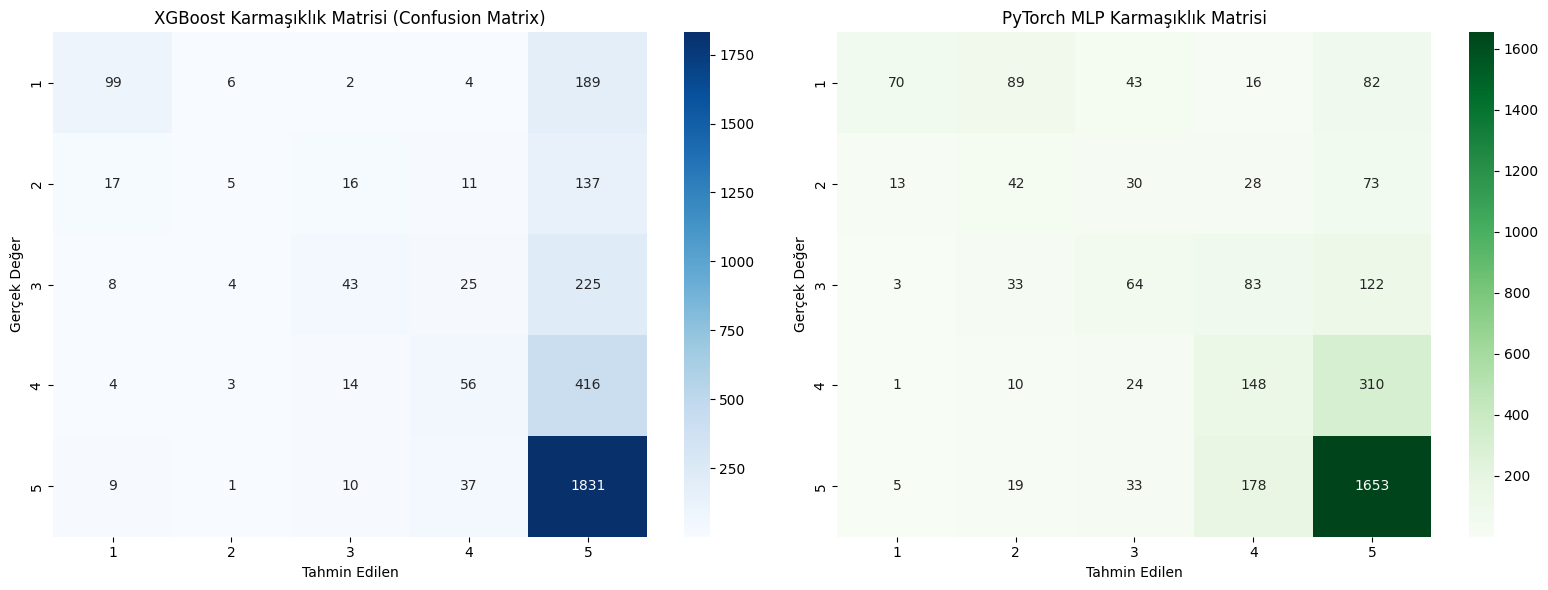

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Grafik boyutlarını ayarla
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- 1. XGBoost Confusion Matrix ---
cm_xgb = confusion_matrix(y_te, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
ax[0].set_title('XGBoost Karmaşıklık Matrisi (Confusion Matrix)')
ax[0].set_xlabel('Tahmin Edilen')
ax[0].set_ylabel('Gerçek Değer')

# --- 2. PyTorch MLP Confusion Matrix ---
cm_mlp = confusion_matrix(yt, yp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens', ax=ax[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
ax[1].set_title('PyTorch MLP Karmaşıklık Matrisi')
ax[1].set_xlabel('Tahmin Edilen')
ax[1].set_ylabel('Gerçek Değer')

plt.tight_layout()
plt.show()

Genel kısa sonuç 
dosyada 1–5 rating için 5 sınıflı metin sınıflandırma yapıldı. Metinler HashingVectorizer ile sayısallaştırılarak iki model denendi: XGBoost ve PyTorch MLP. XGBoost daha yüksek accuracy verse de Macro-F1 düşük kaldı; PyTorch MLP accuracy’de biraz geride olsa da Macro-F1 ve Macro AUC değerlerinde daha iyi performans göstererek sınıflar arasında daha dengeli sonuç verdi. Son karşılaştırma tablosu ve confusion matrix grafikleri modellerin güçlü/zayıf sınıflarını açıkça ortaya koydu.